# 02. 시간대별 및 차종별 교통량 특성 분석

In [ ]:
import geopandas as gpd
import pandas as pd
import folium
import json
import matplotlib.font_manager as fm
import os
import matplotlib.pyplot as plt
from geoband.API import *

## 1) 데이터 불러오기

In [2]:
geo3 = gpd.read_file("08.상세도로망_네트워크.geojson")

iv_risk2 = pd.read_csv("10._추정교통량.csv")
lup1 = gpd.read_file("22._토지이용계획도_(4개_신도시).geojson")

## 2) 4개 신도시 도로망 추출

In [ ]:
# 1. 두 데이터의 좌표계(CRS)를 일치시킵니다. (공간 연산의 필수 단계)
if geo3.crs != lup1.crs:
    lup1 = lup1.to_crs(geo3.crs)

# 2. 공간 결합 (Spatial Join)
geo3 = gpd.sjoin(geo3, lup1[['zoneName', 'geometry']], how='left', predicate='intersects')

# 3. 결합 시 생성되는 불필요한 인덱스 컬럼 제거
if 'index_right' in geo3.columns:
    geo3 = geo3.drop(columns=['index_right'])

# 4. 결과 확인
geo3 = geo3.dropna(subset=['zoneName'])
geo3['zoneName']=geo3['zoneName'].map({'성남판교지구 택지개발사업':'판교신도시',\
                                                 '위례 택지개발사업 예정지구':'위례신도시', \
                                                 '하남미사 공공주택지구 조성사업': '하남미사',\
                                                 '화성동탄지구 택지개발사업':'동탄신도시', '화성동탄2 택지개발사업':'동탄신도시'})

,link_id,up_f_node,up_t_node,dw_f_node,dw_t_node,max_speed,road_name,road_no,road_rank,link_type,...,dw_v_link,m_date,rc_id,rc_name,rc_hist,rc_date,rc_length,old_link_i,geometry,zoneName
6579,571250972,328046,613018,613018,328046,50,경기동로,82,105,32768,...,57125097202,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (127.10044 37.15888, 127.10120 37.1...",동탄신도시
6606,571253198,562032,562033,562033,562032,30,None,0,107,32768,...,57125319802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (127.10976 37.15505, 127.10969 37.1...",동탄신도시
6606,571253198,562032,562033,562033,562032,30,None,0,107,32768,...,57125319802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (127.10976 37.15505, 127.10969 37.1...",동탄신도시
6642,571253534,328046,587095,587095,328046,50,경기동로,82,105,32768,...,57125353402,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (127.10044 37.15888, 127.09998 37.1...",동탄신도시
6648,571253608,587096,587105,587105,587096,50,경기동로,82,105,32768,...,57125360802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (127.10932 37.15572, 127.10826 37.1...",동탄신도시


## 3) 도로 링크와 교통량 데이터 결합

In [ ]:
# 1. v_link_id를 문자열로 변환 후 끝 2자리를 떼어내어 link_id 컬럼 생성
iv_risk2['link_id'] = iv_risk2['v_link_id'].astype(str).str[:-2]

# 2. geo3의 link_id도 매칭을 위해 문자열로 통일 (데이터 타입 일치)
geo3['link_id'] = geo3['link_id'].astype(str)

# 3. Inner Join을 통해 매칭되는 데이터만 남기기
iv_risk2 = pd.merge(iv_risk2, 
                    geo3[['link_id', 'geometry', 'zoneName', 'road_name']], 
                    on='link_id', 
                    how='inner')

# 4. 결과 확인
print(f"필터링 후 남은 행 수: {len(iv_risk2)}")


필터링 후 남은 행 수: 228212


In [ ]:
fe = fm.FontEntry(
    fname=r'./NanumGothic.ttf', 
    name='NanumGothic')                     
fm.fontManager.ttflist.insert(0, fe)            
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'})

## 4) 차종별 교통량 분포 비교

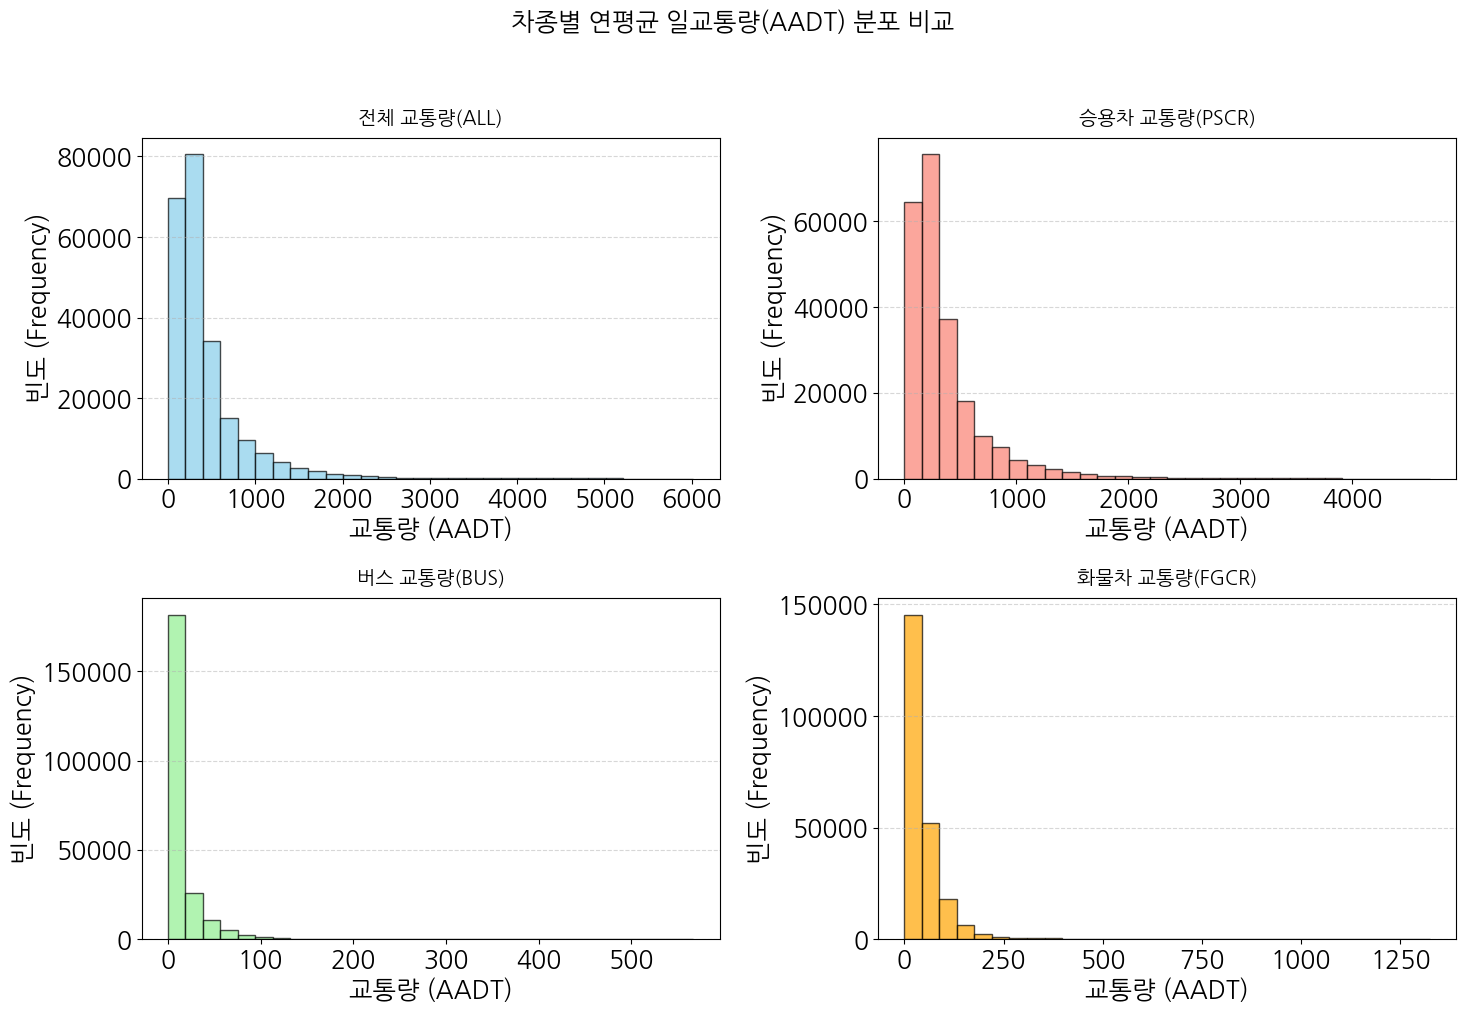

In [ ]:
cols = ['ALL_AADT', 'PSCR_AADT', 'BUS_AADT', 'FGCR_AADT']
titles = ['전체 교통량(ALL)', '승용차 교통량(PSCR)', '버스 교통량(BUS)', '화물차 교통량(FGCR)']
colors = ['skyblue', 'salmon', 'lightgreen', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() 

for i, col in enumerate(cols):
    axes[i].hist(iv_risk2[col], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=14, pad=10)
    axes[i].set_xlabel('교통량 (AADT)')
    axes[i].set_ylabel('빈도 (Frequency)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('차종별 연평균 일교통량(AADT) 분포 비교', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## 5) 분포 왜도 확인

In [ ]:
print(f"모든 차량의 추정교통량의 왜도: {iv_risk2['ALL_AADT'].skew()}")
print(f"승용차의 추정교통량의 왜도: {iv_risk2['PSCR_AADT'].skew()}")
print(f"버스의 추정교통량의 왜도: {iv_risk2['BUS_AADT'].skew()}")
print(f"화물차의 추정교통량의 왜도: {iv_risk2['FGCR_AADT'].skew()}")

모든 차량의 추정교통량의 왜도: 3.4942062266361793
승용차의 추정교통량의 왜도: 3.14748021307328
버스의 추정교통량의 왜도: 6.947554819338589
화물차의 추정교통량의 왜도: 6.774771156998733


## 6) 시간대별 평균 교통량 집계

In [ ]:
iv_risk2=iv_risk2.groupby('timeslot').mean(numeric_only=True).reset_index()

,timeslot,v_link_id,road_rank,k_length,sido_id,sigungu_id,emd_id,ALL_AADT,PSCR_AADT,BUS_AADT,FGCR_AADT
0,0,5.829910e+10,106.727806,0.113048,30094.106363,30272.486731,3.027316e+07,145.007567,123.891293,4.246403,16.862517
1,1,5.836880e+10,106.710180,0.117415,30048.938135,30226.604224,3.022728e+07,103.004155,85.915397,2.725416,14.338181
2,2,5.834527e+10,106.704258,0.119413,30047.159571,30223.225184,3.022390e+07,87.425039,71.781691,2.194669,13.426125
3,3,5.840364e+10,106.696326,0.120492,30006.468937,30183.871354,3.018455e+07,109.695716,90.438179,2.680825,16.583913
4,4,5.840709e+10,106.706169,0.117610,30028.293135,30205.604128,3.020628e+07,247.724954,209.585111,6.039657,32.097866


## 7) 시간대별 교통량 시각화

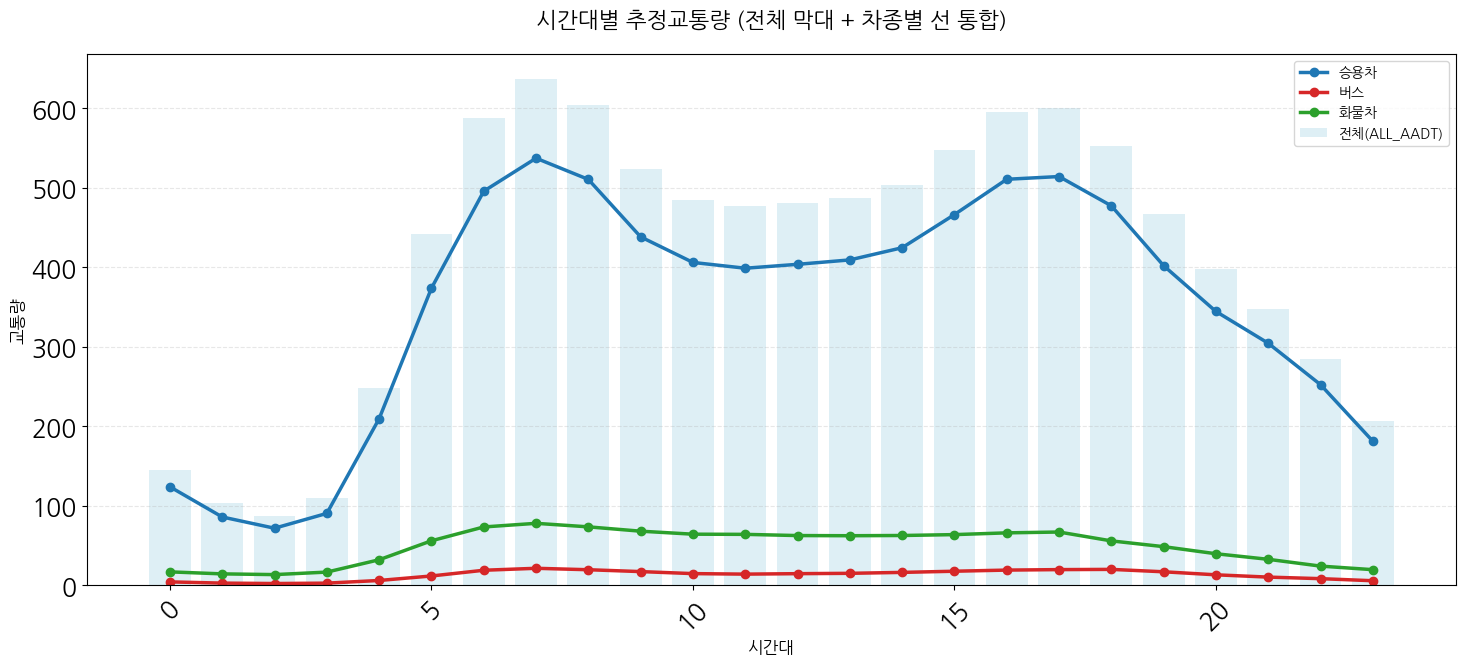

In [ ]:
plt.rc('font', family='NanumGothic')
plt.figure(figsize=(15, 7))

plt.bar(iv_risk2['timeslot'], iv_risk2['ALL_AADT'], color='lightblue', alpha=0.4, label='전체(ALL_AADT)', width=0.8)

cols = ['PSCR_AADT', 'BUS_AADT', 'FGCR_AADT']
labels = ['승용차', '버스', '화물차']
colors = ['#1f77b4', '#d62728', '#2ca02c'] 
for col, label, color in zip(cols, labels, colors):
    plt.plot(iv_risk2['timeslot'], iv_risk2[col], marker='o', label=label, color=color, linewidth=2.5)

plt.title('시간대별 추정교통량 (전체 막대 + 차종별 선 통합)', fontsize=16, pad=20)
plt.xlabel('시간대', fontsize=12)
plt.ylabel('교통량', fontsize=12)

plt.legend(loc='upper right', fontsize=10)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
